In [22]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [12]:
conv_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [13]:
model = Sequential()

model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,128,769 (92.04 MB)

 Trainable params: 24,075,649 (91.84 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [15]:
conv_base.trainable = False

In [16]:
def resnet_prep(img_array):
    img = Image.fromarray(img_array.astype('uint8'))
    if img.mode != 'RGB':
        img = img.convert('RGB')
    final_img = np.array(img)
    
    # Apply official ResNet preprocessing 
    return preprocess_input(final_img)

In [17]:
batch_size = 32

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest',
    preprocessing_function=resnet_prep
)

test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_prep
)

train_generator = train_datagen.flow_from_directory(
    './dataset/train',
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    './dataset/test',
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

val_generator = test_datagen.flow_from_directory(
    './dataset/val',
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 549 images belonging to 2 classes.
Found 110 images belonging to 2 classes.
Found 74 images belonging to 2 classes.


In [18]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [20]:
history = model.fit(
        train_generator,
        epochs=25,
        validation_data=val_generator,
        callbacks=[early_stop]
)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6976 - loss: 0.5888 - val_accuracy: 0.9189 - val_loss: 0.2809
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9235 - loss: 0.2591 - val_accuracy: 0.9730 - val_loss: 0.1576
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9454 - loss: 0.1711 - val_accuracy: 0.9730 - val_loss: 0.0988
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9545 - loss: 0.1359 - val_accuracy: 0.9865 - val_loss: 0.0745
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9563 - loss: 0.1204 - val_accuracy: 0.9865 - val_loss: 0.0630
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9636 - loss: 0.0990 - val_accuracy: 0.9865 - val_loss: 0.0542
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9745 - loss: 0.0875 - val_accuracy: 0.9865 - val_loss: 0.0459
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9763 - loss: 0.0787 - val_accuracy: 0.9865 - val_loss:

In [21]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9727 - loss: 0.0536
Test Accuracy: 97.27%
Test Loss: 0.0536


In [23]:
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [24]:
y_true = test_generator.classes

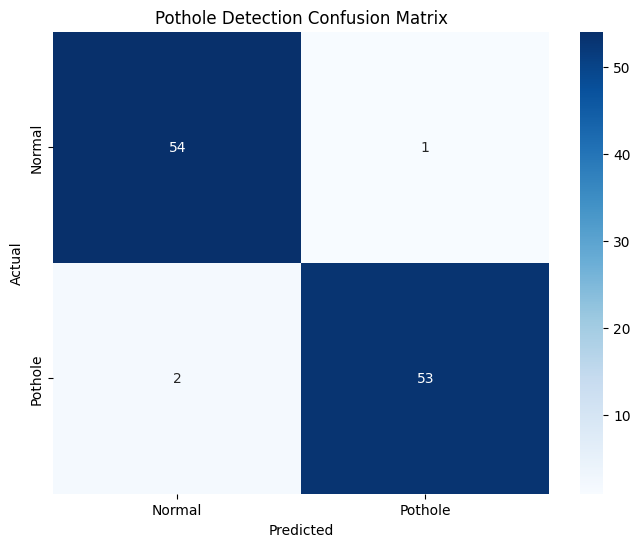

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97        55
     Pothole       0.98      0.96      0.97        55

    accuracy                           0.97       110
   macro avg       0.97      0.97      0.97       110
weighted avg       0.97      0.97      0.97       110



In [25]:
cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pothole'], 
            yticklabels=['Normal', 'Pothole'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Pothole Detection Confusion Matrix')
plt.show()

# Detailed Report (Precision, Recall, F1)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pothole']))

In [ ]:
def predict_external_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    
    img_array = convert_to_rgb(img_array)
    
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))
    
    prediction = model.predict(img_preprocessed)[0][0]
    
    plt.imshow(img)
    plt.axis('off')
    status = "POTHOLE" if prediction > 0.5 else "NORMAL"
    plt.title(f"Prediction: {status} ({prediction*100:.2f}% confidence)")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


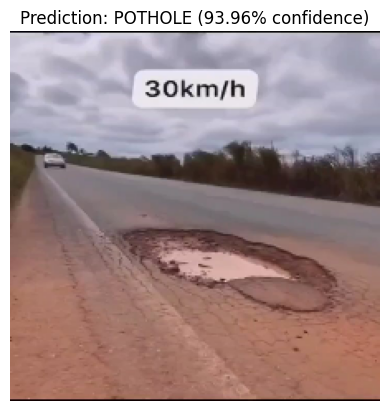

In [43]:
predict_external_image('./testing/Pothole_Test.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


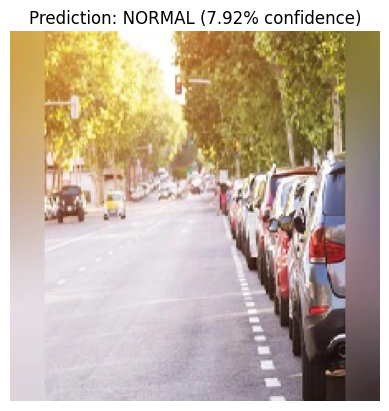

In [41]:
predict_external_image('./testing/Plain_Test_1.jpg')

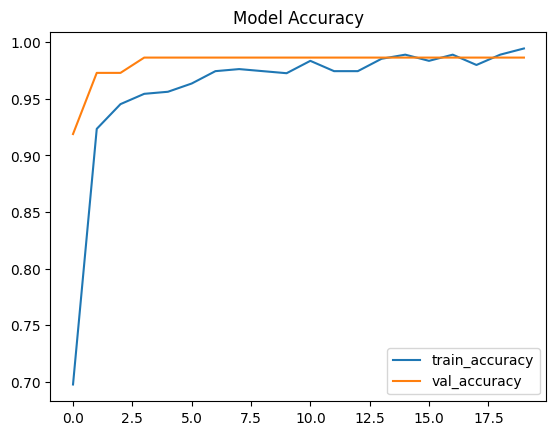

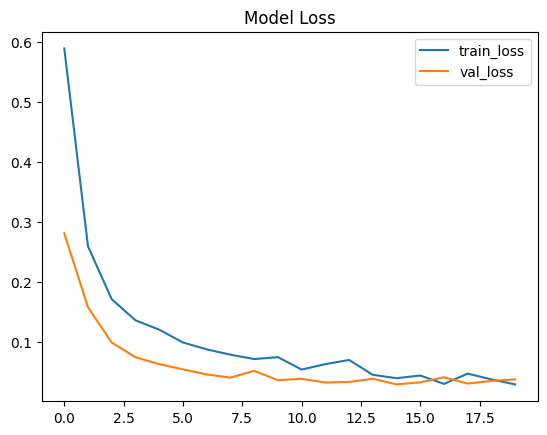

In [42]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [45]:
model.save('./model/pothole_detection_model.h5')